# 03 · Diebold-Yilmaz Spillover Index

**Project:** War Shocks & Global Financial Risk Spillover  
**Input:** `data/processed/rolling_volatility.xlsx`, `war_dummies.xlsx`  
**Output:** `data/processed/spillover_index.xlsx`, `outputs/figures/fig6–fig9`

### Method: Diebold-Yilmaz (2012)
Generalised FEVD (Pesaran & Shin 1998) — order-invariant, H = 10 days.  
VAR lag order selected by AIC. Total Spillover Index = off-diagonal sum / N × 100.

### Role in the research logic
1. **Static DY** (training period): identify *who* transmits risk to *whom* — motivation for nonlinear modelling  
2. **Rolling DY** (full sample): show *when* spillovers intensify — war events as structural breaks  
3. **Fig 9** (new): formal Welch t-test of Calm vs War regime means — turns description into empirical evidence

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from src.data_loader import DATA_RAW_DIR, DATA_PROC_DIR
from src.spillover import (
    static_spillover,
    rolling_spillover,
    plot_spillover_ts,
    plot_spillover_heatmaps,
    plot_net_spillover,
    plot_war_structural_break,
    plot_vix_conditional_spillover, 
    save_spillover,
    EQUITY_COLS,
)

H, W = 10, 200  # FEVD horizon, rolling window

TRAIN_START, TRAIN_END = "2000-01-01", "2018-12-31"
VAL_START,   VAL_END   = "2019-01-01", "2021-12-31"
TEST_START,  TEST_END  = "2022-01-01", "2025-12-31"

---
## 1  Load Data

In [2]:
vol_df    = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                           index_col=0, parse_dates=True)
war_dummy = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                           index_col=0, parse_dates=True)
events    = pd.read_excel(f"{DATA_RAW_DIR}/war_events.xlsx",
                           parse_dates=["start_date", "end_date"])

print(f"vol_df    : {vol_df.shape}")
print(f"war_dummy : {war_dummy.shape}  columns: {list(war_dummy.columns)}")
print(f"events    : {len(events)} war events")

vol_df    : (6538, 8)
war_dummy : (6538, 5)  columns: ['mideast_war', 'high_intensity', 'gfc_crisis', 'covid_crisis', 'any_crisis']
events    : 7 war events


---
## 2  Sub-Sample Masks (Training Period)

In [3]:
war_aligned = war_dummy.reindex(vol_df.index).fillna(0)
vol_clean   = vol_df.dropna()
vol_train   = vol_clean.loc[TRAIN_START:TRAIN_END]
dum_train   = war_aligned.loc[TRAIN_START:TRAIN_END]

has_crisis = "any_crisis" in dum_train.columns

if has_crisis:
    pure_calm_mask = (dum_train["mideast_war"] == 0) & (dum_train["any_crisis"] == 0)
    war_only_mask  = (dum_train["mideast_war"] == 1) & (dum_train["any_crisis"] == 0)
else:
    pure_calm_mask = dum_train["mideast_war"] == 0
    war_only_mask  = dum_train["mideast_war"] == 1

vol_pure_calm = vol_train[pure_calm_mask]
vol_war_only  = vol_train[war_only_mask]

print(f"Training period: {len(vol_train)} obs")
print(f"  A: Pure Calm : {pure_calm_mask.sum():5d} obs")
print(f"  B: War Only  : {war_only_mask.sum():5d} obs")

Training period: 3675 obs
  A: Pure Calm :  4388 obs
  B: War Only  :   182 obs


---
## 3  Static Spillover — Training Period

Estimated on train data only (2006–2018) to avoid data leakage into notebooks 04–07.  
Sub-sample A vs B isolates the pure war effect, controlling for financial crises.

In [4]:
print("=" * 55)
print("TRAINING PERIOD — full train window")
print("=" * 55)
summary_train = static_spillover(vol_train, label="Train 2006-2018", H=H)
print("\n── Net (positive = transmitter) ──")
print(summary_train["net"].round(2).sort_values(ascending=False).to_string())

print("\n" + "=" * 55)
print("A: PURE CALM")
print("=" * 55)
summary_calm = static_spillover(vol_pure_calm, label="Pure Calm (train)", H=H)

print("\n" + "=" * 55)
print("B: WAR ONLY")
print("=" * 55)
summary_war = static_spillover(vol_war_only, label="War Only (train)", H=H)

base = summary_calm["total"]
print(f"\n  War/Calm ratio: {summary_war['total']/base:.3f}x  "
      f"(+{summary_war['total']-base:.2f} pp)")

TRAINING PERIOD — full train window
  [Train 2006-2018] Total Spillover = 60.52%  (VAR, lag=5)

── Net (positive = transmitter) ──
FTSE100     2.57
SP500       2.52
CAC40       2.03
DAX         1.58
SSE        -1.16
HangSeng   -1.60
KOSPI      -2.78
Nikkei     -3.17

A: PURE CALM
  [Pure Calm (train)] Total Spillover = 54.93%  (VAR, lag=3)

B: WAR ONLY
  [War Only (train)] Total Spillover = 69.42%  (VAR, lag=2)

  War/Calm ratio: 1.264x  (+14.49 pp)


---
## 4  Save Spillover Matrices

In [5]:
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

for summary, name in [(summary_train, "train"),
                      (summary_calm,  "calm"),
                      (summary_war,   "war")]:
    path = os.path.join(TABLE_DIR, f"table_spillover_{name}.xlsx")
    summary["matrix_df"].round(2).to_excel(path)
    print(f"Saved → {path}")

Saved → ..\outputs\tables\table_spillover_train.xlsx
Saved → ..\outputs\tables\table_spillover_calm.xlsx
Saved → ..\outputs\tables\table_spillover_war.xlsx


---
## 5  Fig 7 · Spillover Heatmaps: Calm vs War

Off-diagonal values show directional spillover between market pairs.  
Any increase in off-diagonal intensity from Calm→War reflects the war effect on transmission structure.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig7_spillover_heatmaps.png


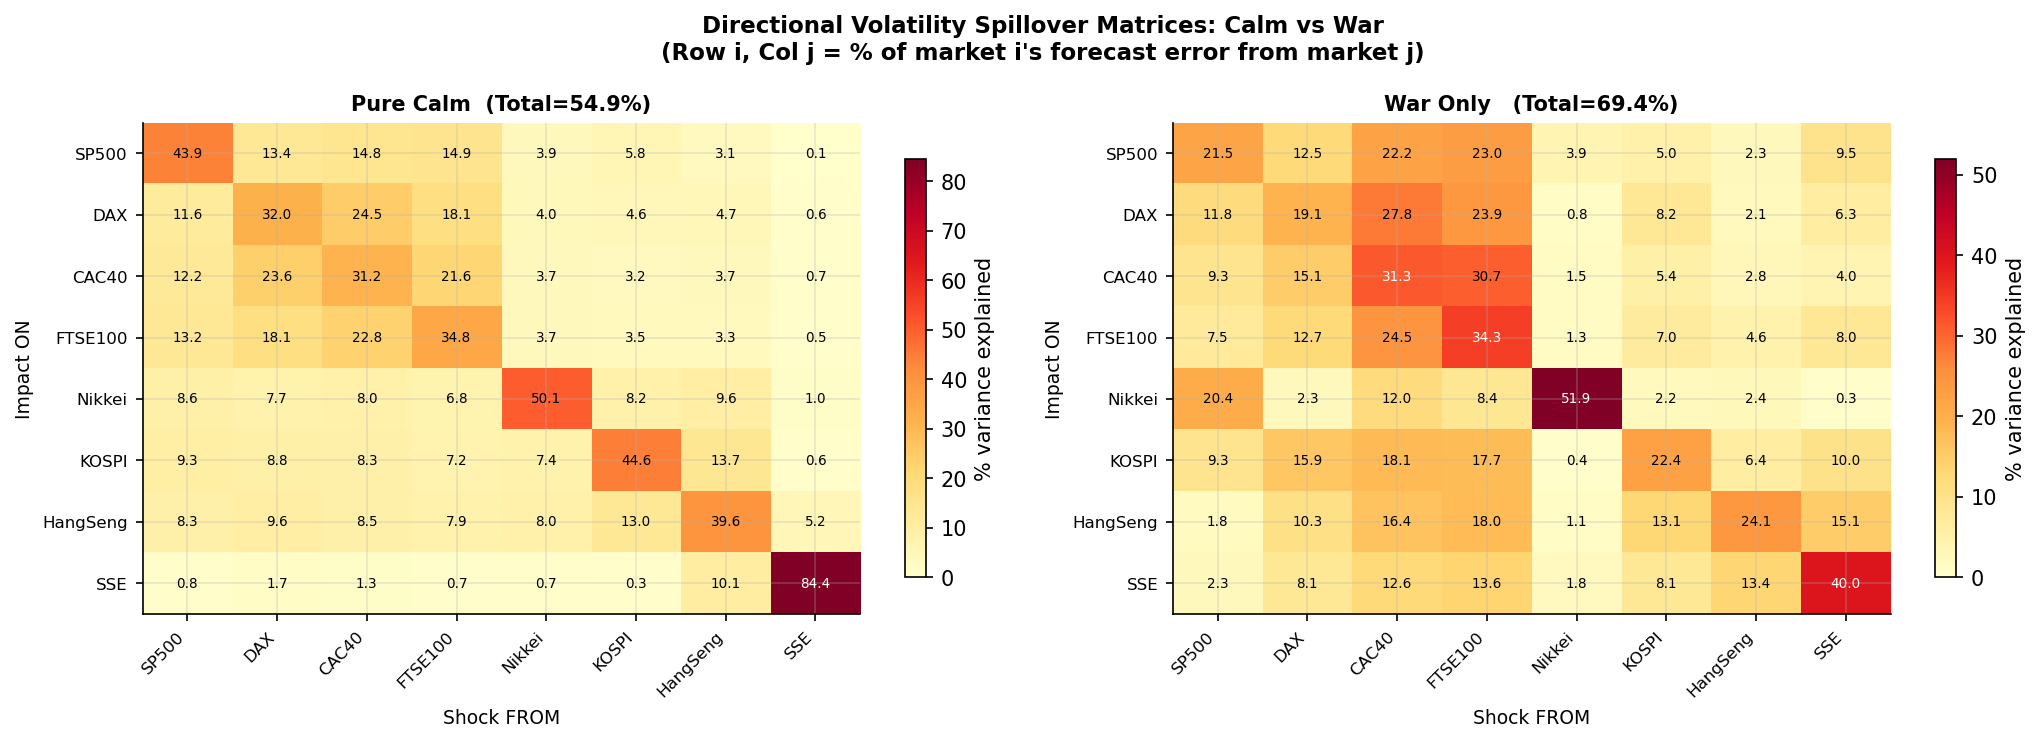

In [6]:
plot_spillover_heatmaps(summary_calm, summary_war)

---
## 6  Fig 8 · Net Spillover Bar Chart

Positive = net risk transmitter (gives more than it receives).  
This asymmetry motivates the use of models that capture cross-market nonlinear dynamics.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig8_net_spillover.png


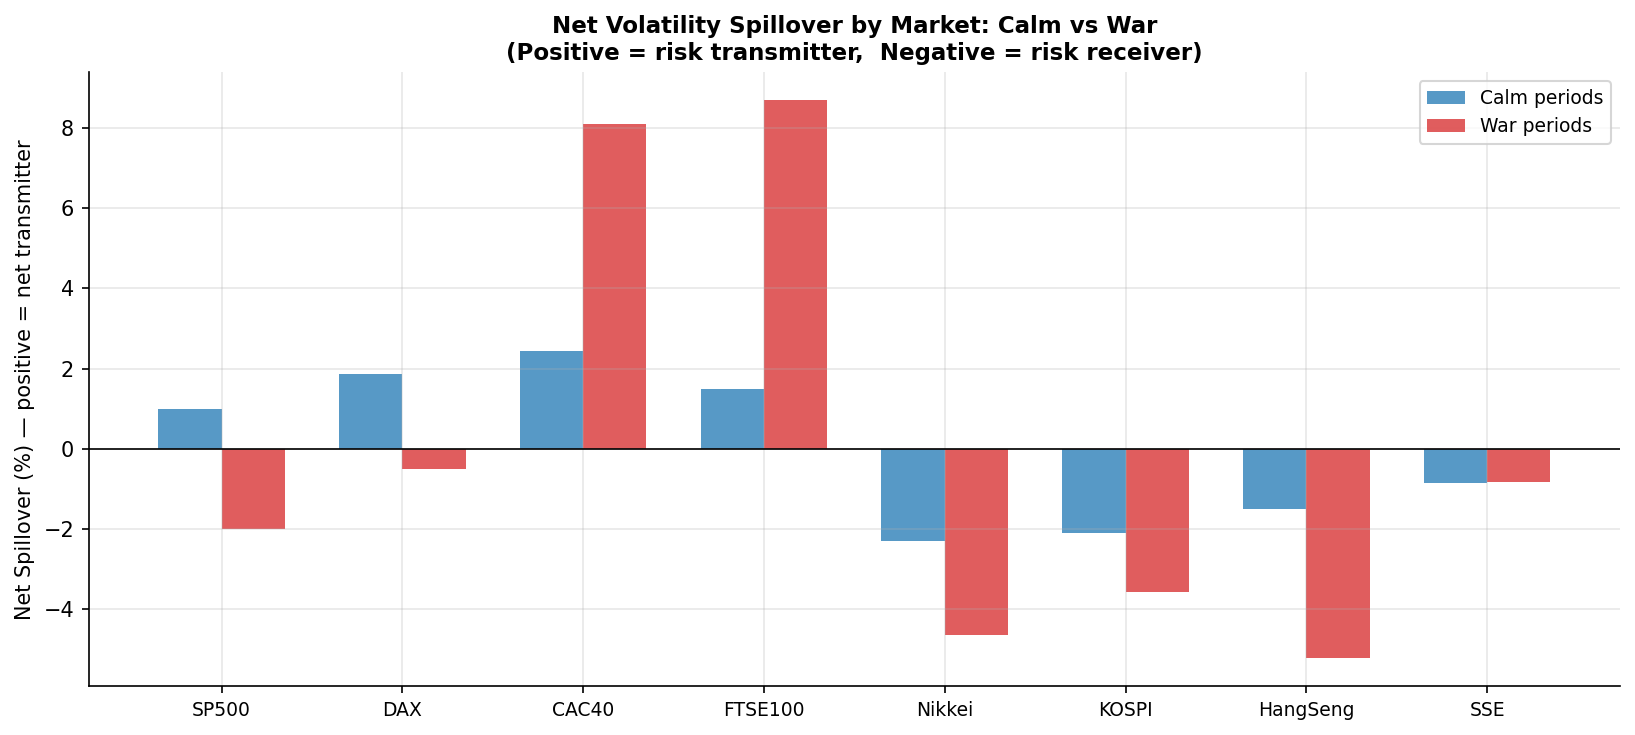

In [7]:
plot_net_spillover(summary_calm, summary_war)

---
## 7  Rolling Spillover Index (Full Sample)

Full-sample rolling series preserves time-series continuity.  
The Soleimani/COVID window (2020-01-03 – 2020-03-31) is retained here  
but excluded from regime means in Fig 9.

In [8]:
spillover_ts = rolling_spillover(
    vol_clean, window=W, H=H, step=1, maxlags=5)
print(spillover_ts["total_spillover"].describe().round(2))

  Rolling spillover: window=200, H=10, n_windows≈5080
    ... 200 windows done (latest: 2002-06-24)
    ... 400 windows done (latest: 2003-07-25)
    ... 600 windows done (latest: 2004-08-23)
    ... 800 windows done (latest: 2005-09-19)
    ... 1000 windows done (latest: 2006-11-16)
    ... 1200 windows done (latest: 2007-12-12)
    ... 1400 windows done (latest: 2008-12-03)
    ... 1600 windows done (latest: 2009-11-25)
    ... 1800 windows done (latest: 2010-11-16)
    ... 2000 windows done (latest: 2011-10-05)
    ... 2200 windows done (latest: 2012-09-26)
    ... 2400 windows done (latest: 2013-09-20)
    ... 2600 windows done (latest: 2014-09-12)
    ... 2800 windows done (latest: 2015-09-03)
    ... 3000 windows done (latest: 2016-08-25)
    ... 3200 windows done (latest: 2017-08-17)
    ... 3400 windows done (latest: 2018-08-09)
    ... 3600 windows done (latest: 2019-09-06)
    ... 3800 windows done (latest: 2020-08-28)
    ... 4000 windows done (latest: 2021-08-20)
    ... 42

---
## 8  Attach Regime Flags to Rolling Series

In [9]:
spill = spillover_ts.drop(columns=["lag_order"], errors="ignore").copy()

# Attach raw regime flags
for col in ["mideast_war", "any_crisis", "high_intensity"]:
    if col in war_aligned.columns:
        spill[col] = war_aligned.reindex(spill.index)[col].fillna(0)

# War-dominant window flag 
# Calculate the proportion of mideast_war=1 within 200 days
# If proportion > WAR_THRESH, set as war-dominant window
WAR_THRESH = 0.3

war_ratio = (
    war_aligned["mideast_war"]
    .reindex(vol_clean.index).fillna(0)
    .rolling(W).mean()
)
spill["war_ratio"]    = war_ratio.reindex(spill.index).fillna(0)
spill["war_dominant"] = (spill["war_ratio"] > WAR_THRESH).astype(int)

# Identify net spillover columns produced by rolling_spillover
net_cols = [c for c in spill.columns if c.startswith("net_")]
print(f"Total spillover columns : {len(net_cols)} net + 1 total")
print(f"Net cols: {net_cols}")
print(f"war_dominant=1 obs      : {spill['war_dominant'].sum()}")
print(f"Calm obs (excl crisis)  : {((spill['war_dominant']==0)&(spill['any_crisis']==0)).sum()}")
print()
print(spill[["total_spillover"] + net_cols[:3]].head())


Total spillover columns : 8 net + 1 total
Net cols: ['net_SP500', 'net_DAX', 'net_CAC40', 'net_FTSE100', 'net_Nikkei', 'net_KOSPI', 'net_HangSeng', 'net_SSE']
war_dominant=1 obs      : 184
Calm obs (excl crisis)  : 4386

            total_spillover  net_SP500   net_DAX  net_CAC40
Date                                                       
2001-04-17        42.077769  -3.769505  2.741613  -0.175428
2001-04-18        42.233686  -3.303099  2.750600  -0.010756
2001-04-19        42.182565  -3.570372  2.877062  -0.411325
2001-04-20        41.908740  -3.446849  2.841003  -0.403395
2001-04-23        42.710577  -2.469127  2.442969   0.083029


---
## 9  Fig 9 · Rolling Total Spillover Index

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig9_spillover_timeseries.png


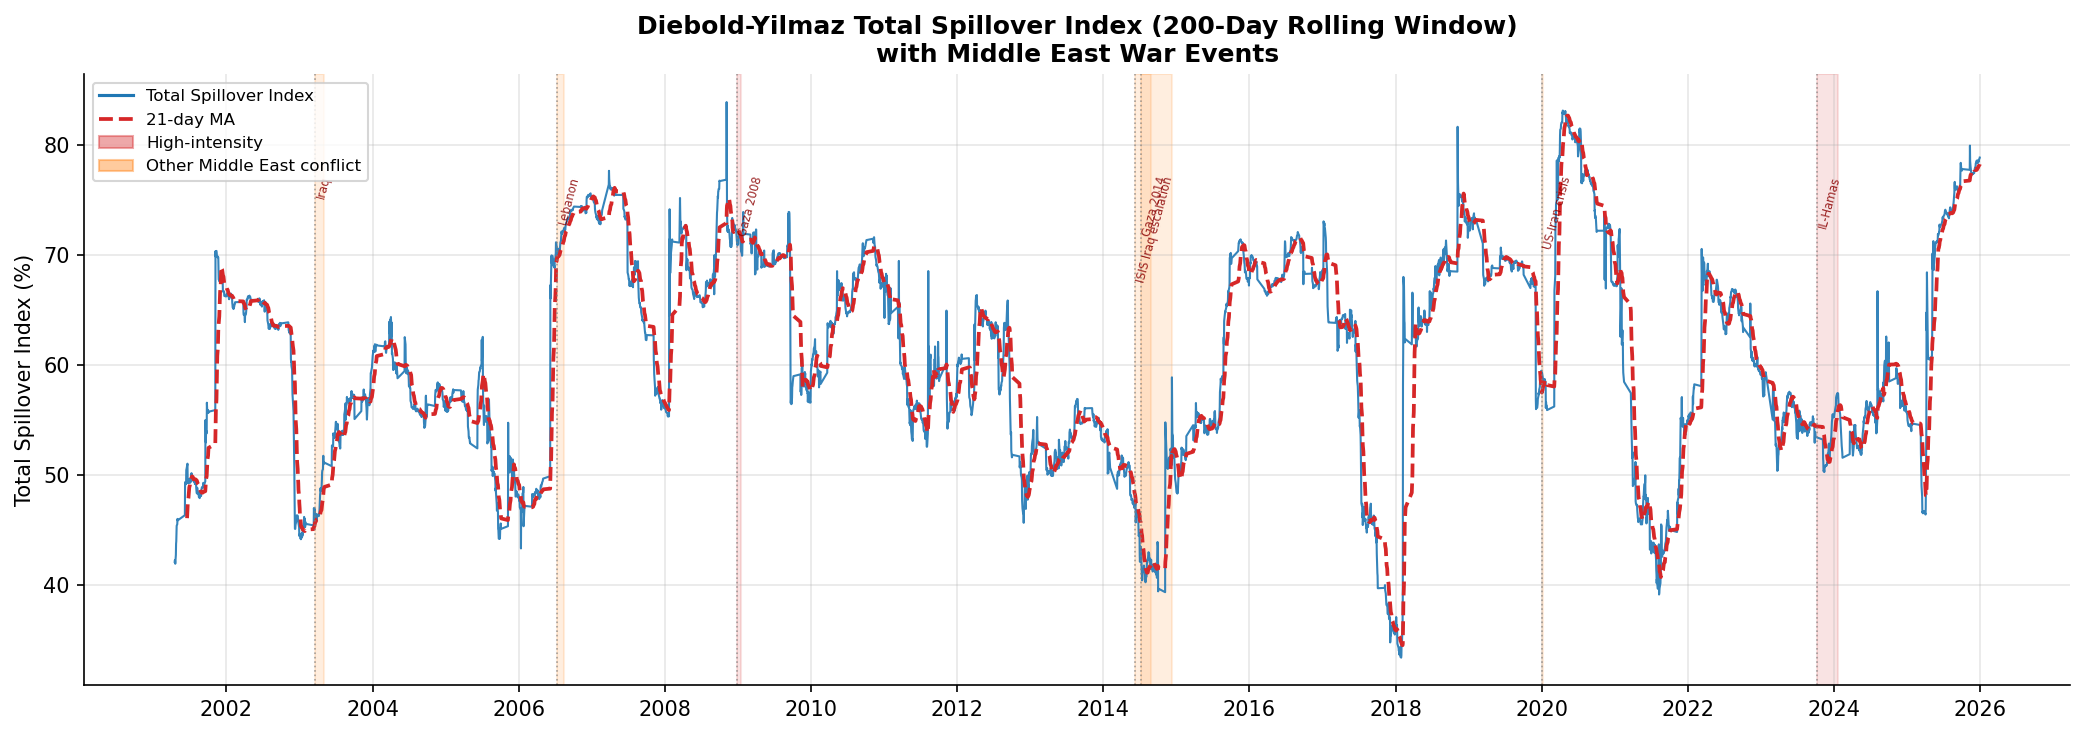

In [10]:
plot_spillover_ts(spillover_ts, events, end_date=TEST_END)

---
## 10  Fig 10 · War-Shock Structural Break Analysis

If war regimes are statistically associated with higher total spillover, this constitutes empirical evidence that geopolitical conflict alters volatility transmission structure, directly motivating nonlinear modelling in notebooks 04–07.

Method: Welch t-test (unequal variance) comparing rolling spillover means across Calm vs War regimes, with COVID window excluded.

War Structural Break — Welch t-test
  Calm : 60.10%  (n=4386)
  War  : 51.76%  (n=184)
  Δ = -8.34 pp   t = 23.759   p = 0.0000  ***
  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig10_war_structural_break.png


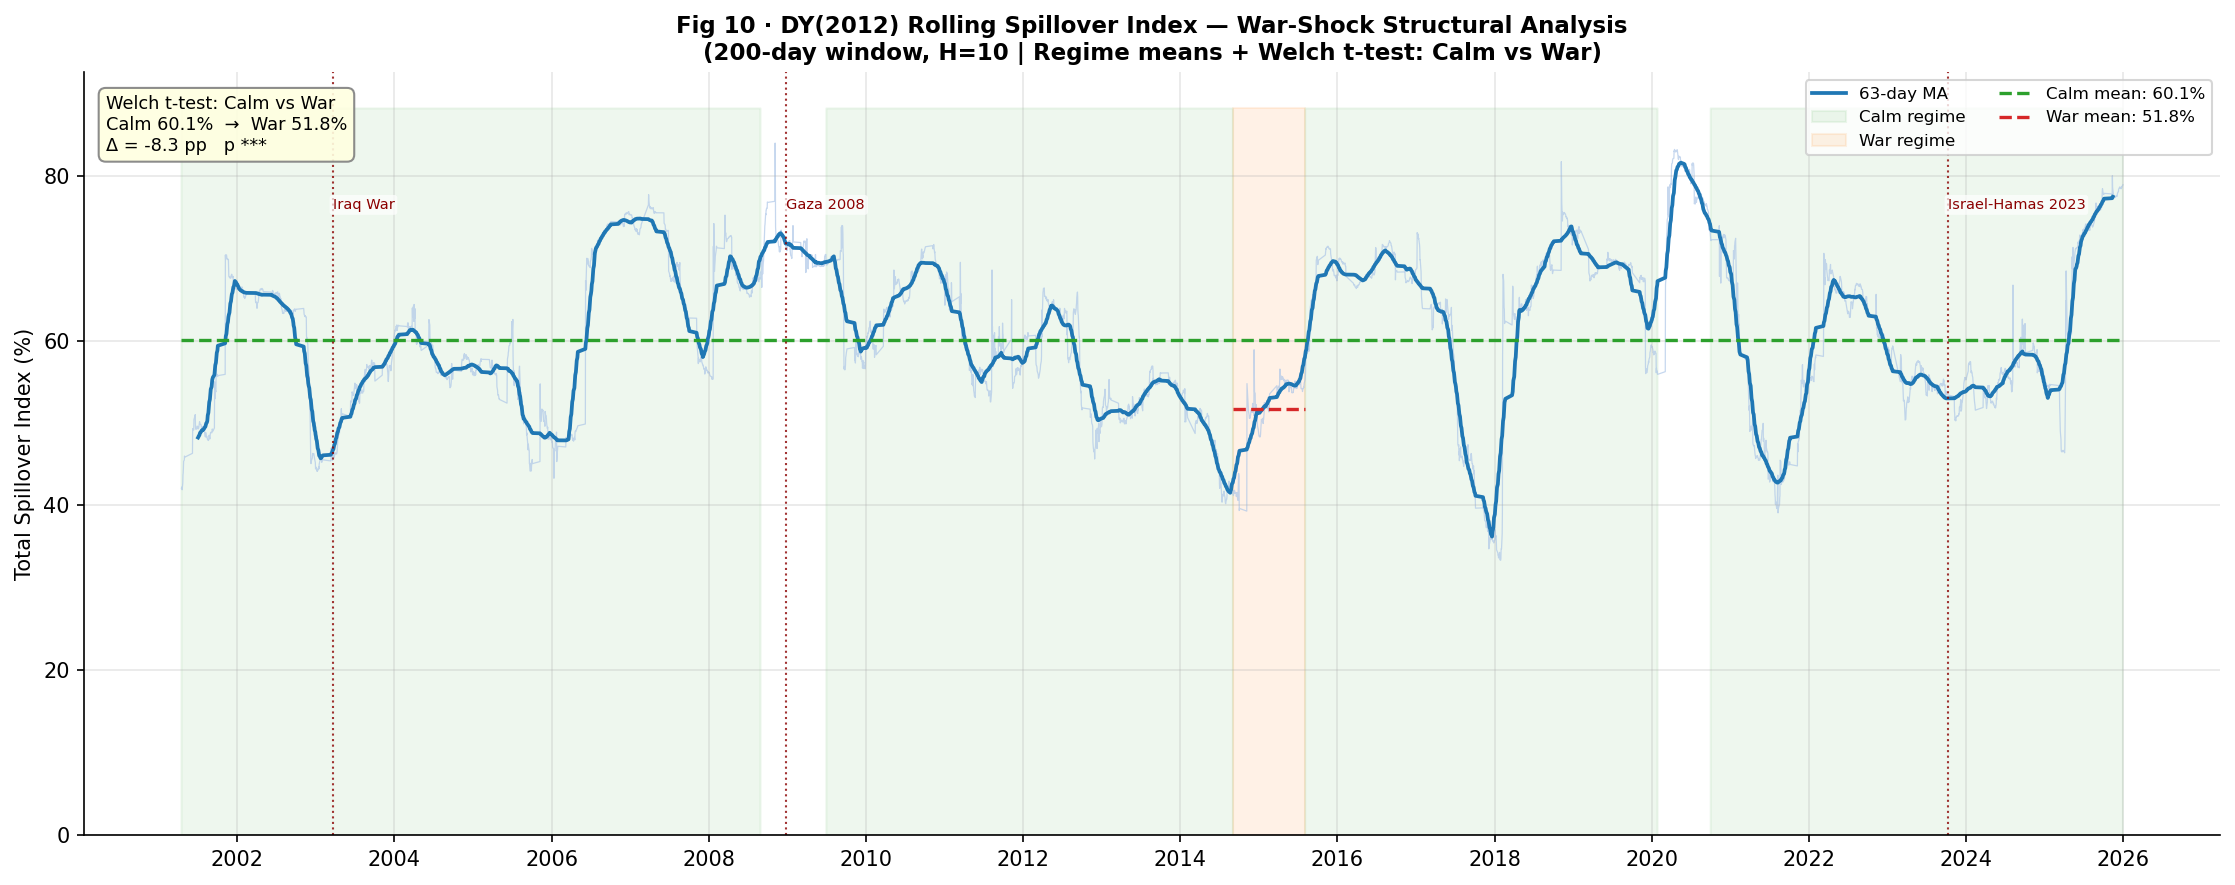

In [11]:
break_stats = plot_war_structural_break(spill)

---
## 11b  VIX-Conditional War Effect (Robustness Check)

**Motivation:** Fig 9 showed war-dominant windows have *lower* mean spillover than calm.
A key confound is that Middle East wars (2014–2016 cluster) coincide with a
low-VIX macro environment, making the raw war vs calm comparison biased.

**Design:** Split the full rolling sample into VIX terciles (Low / Mid / High).
Within each tercile compare war vs non-war spillover via Welch t-test.
If the war premium persists (or reverses consistently) across all VIX regimes,
the effect is not an artefact of VIX-war collinearity.

VIX-CONDITIONAL WAR EFFECT ON TOTAL SPILLOVER
VIX Regime    VIX avg     War   Non-War   Premium   Prem%       t       p  sig  n_war   n_nw
------------------------------------------------------------------------
Low VIX          12.6   49.43     58.66     -9.24  -15.7% -13.227  0.0000  ***    149   1479
Mid VIX          17.4   55.60     59.91     -4.31   -7.2%  -1.946  0.0594    *     37   1589
High VIX         28.4   55.63     64.73     -9.10  -14.1%  -4.999  0.0000  ***     41   1585
  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig10_vix_conditional_spillover.png


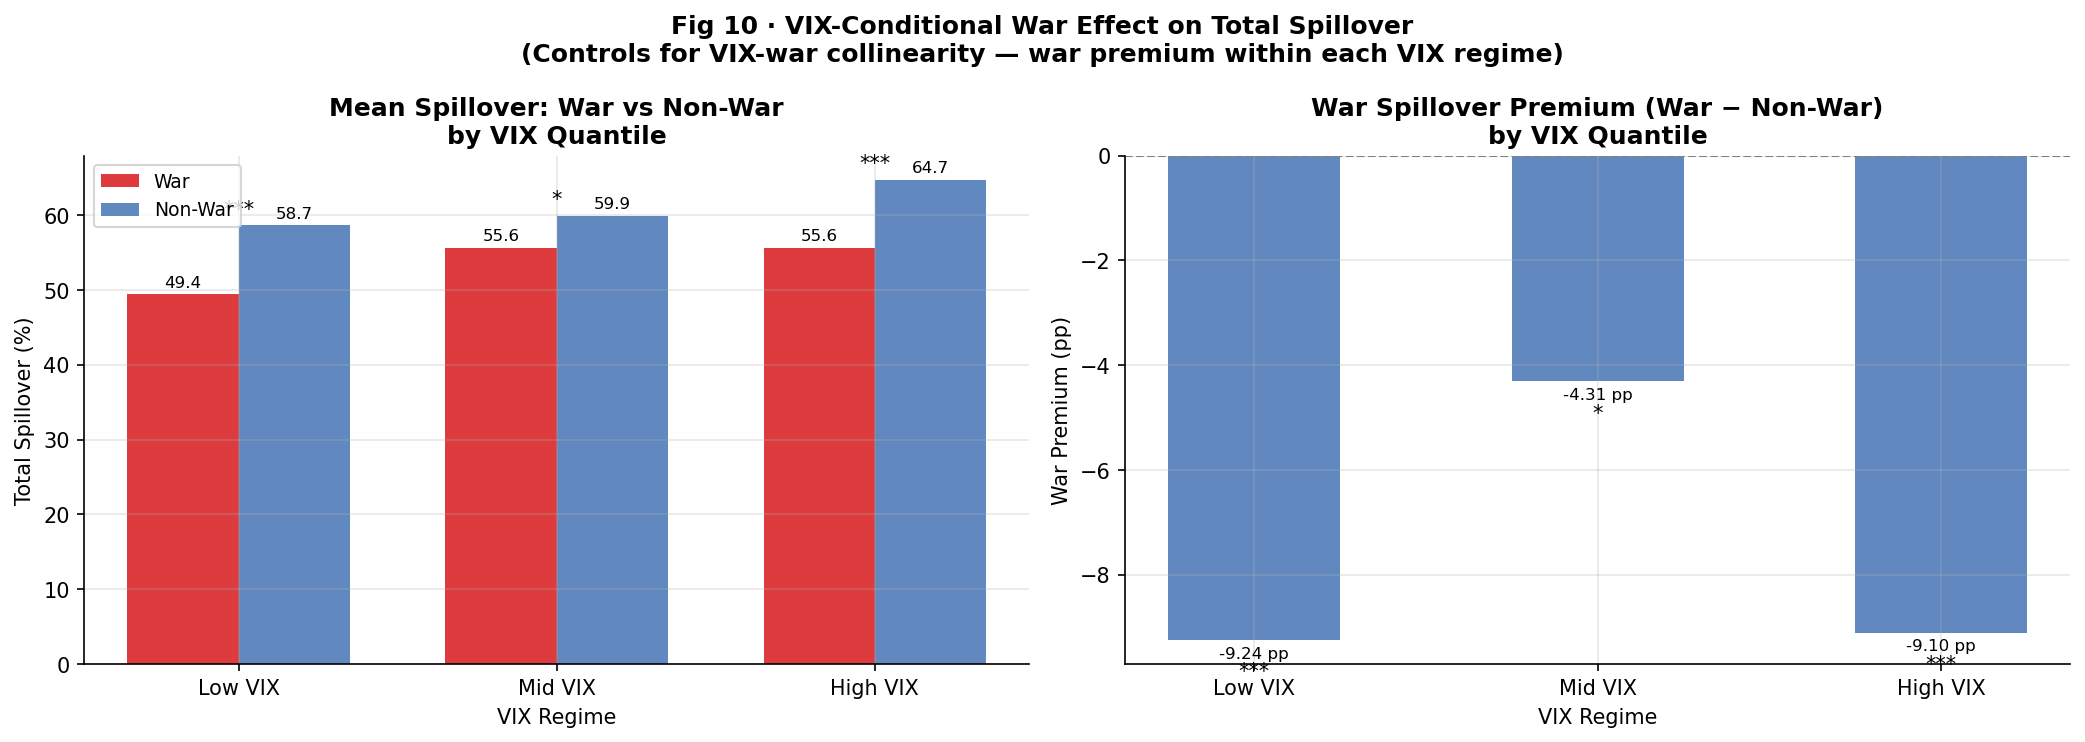

Saved → outputs/tables/table_vix_conditional_war.xlsx


In [14]:
# Requires all_variables_aligned.xlsx for VIX series
all_vars = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",
                          index_col=0, parse_dates=True)

vix_war_results = plot_vix_conditional_spillover(
    spill_df    = spill,
    all_vars_df = all_vars,
    war_col     = "mideast_war",
    vix_col     = "VIX",
    n_quantiles = 3,
)

# Save robustness table
vix_war_results.to_excel(
    os.path.join(TABLE_DIR, "table_vix_conditional_war.xlsx"),
    index=False)
print("Saved → outputs/tables/table_vix_conditional_war.xlsx")

---
## 11  Save Rolling Spillover Index

In [ ]:
save_spillover(spill, "spillover_index.xlsx")
print(f"Saved → data/processed/spillover_index.xlsx")
print(f"Columns saved: {list(spill.columns)}")
print(f"Shape: {spill.shape}")

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\data\processed\spillover_index.xlsx  (4880, 14)
Saved → data/processed/spillover_index.xlsx
Columns saved: ['total_spillover', 'net_SP500', 'net_DAX', 'net_CAC40', 'net_FTSE100', 'net_Nikkei', 'net_KOSPI', 'net_HangSeng', 'net_SSE', 'mideast_war', 'any_crisis', 'high_intensity', 'war_ratio', 'war_dominant']
Shape: (4880, 14)


---
**Next → `04_var_baseline.ipynb`**